# FSCI 396: Correlation and ANOVA

------------------
Welcome to today's tutorial! 
Today we'll use Python in Jupyter Notebook to perform some common statistical analyses.
We will cover: Correlations and ANOVA 


The goal is to see how we can analyze data with Python, just like we discussed in lectures.


### Steps to Debugging 

I am here to help you! But before you contact me, make sure you have tried the following:
1. Ensure that all brackets and parentheses are paired.
2. Ensure that your code does not have any typos (eg. when calling your data file).
3. Ensure you did not add additional spaces (eg. when calling your data file).
4. You have restarted your kernel and reun your code. 
5. You have tried to understand the error message. 

If you have done all of these things, I am very happy to help! 

In [1]:
# Import Modules
# ---------------

# Modules in Python are like library books. 
# Each book contains a set of instructions or “recipes” for doing specific tasks.
# - pandas: for handling and analyzing tables of data
# - numpy: for numerical calculations
# - seaborn & matplotlib: for making plots
# - statsmodels: for running statistical models and regression analysis
# - statsmodels.formula.api (smf): convenient formula interface
# - statsmodels.api (sm): tools for more advanced statistical modeling
# - semopy: used for structural equation modelling 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
import semopy

# Ignore Warnings for simplicity
import warnings
warnings.filterwarnings('ignore')

# Quick check to see if modules loaded correctly
print("Modules loaded successfully!")


Modules loaded successfully!


In [2]:
# These are the functions to calculate the values of interest for this study. 
# You do not have to touch this if you do not want to 

def DescripStats(df,fields):
    # Calculate the descriptive stats
    min_values = df[fields].min(axis=0)
    max_values = df[fields].max(axis=0)
    mean_values = df[fields].mean(axis=0)
    # median_vals = df[fields].median(axis=0)
    std_values = df[fields].std(axis=0)
    skew_values = df[fields].skew(axis=0)
    kurtosis_values = df[fields].kurtosis(axis=0)

    # Create Table 1
    table1 = pd.DataFrame({
        'Minimum': min_values,
        'Maximum': max_values,
        'Mean': mean_values,
    #     'Median': median_values,
        'SD': std_values,
        'Skewness': skew_values,
        'Kurtosis': kurtosis_values
    })
    return table1

def Correl(df):
    table3 = df.loc[:, 'Rehearsal':'Anxiety_group'].corr()
    return table3

print('Functions have successfully been defined!')

Functions have successfully been defined!


In [3]:
# Load datafile/dataframe (df) from CSV
# --------------------------------------

# Here we load our data. Make sure the CSV file is in the same folder as this notebook.

# If your file is excel, use these two lines:
filename = 'SampleData.xlsx'    # Name of your file
df = pd.read_excel(filename)         # Read the CSV into a DataFrame

# If your data is .csv, use these two lines: 
# filename = 'SampleData.csv'    # Name of your file
# df = pd.read_csv(filename)         # Read the CSV into a DataFrame

# Checkpoint to ensure the file has been loaded 
print(filename, 'has been loaded')


Anon_Compiled_Qual_2024-2025_Grades.xlsx has been loaded


# Descriptive Statistics

- **Minimum (min)** --> Shows the lower bound of responses. 


- **Maximum (max)** --> Shows the upper bound of responses.


- **Mean (average)** --> Gives the “typical” score, but is sensitive to outliers.


- **Standard Deviation (std)** --> How spread out the values are from the mean.  \
      *Small std = values clustered tightly.* \
      *large std = values widely spread.*  

- **Skewness** --> Whether the distribution is symmetric. \
       *Skew ≈ 0 --> roughly symmetric.* \
       *Skew > 0 --> long tail to the right (more low values, fewer high).* \
       *Skew < 0 --> long tail to the left (more high values, fewer low).*

- **Kurtosis** --> How narrow/wide or tall/short the distribution is compared to a normal curve. \
       *Kurtosis ≈ 0 --> similar to normal distribution.* \
       *Kurtosis > 0 --> heavier tails & sharper peak (more extreme values).* \
       *Kurtosis < 0 --> flatter peak & lighter tails.*


In [5]:
fields = ['Rehearsal','Elaboration','State_Anxiety','SelfEfficacy','Anxiety_test','Anxiety_writing','Anxiety_speaking','Anxiety_group']
DescripStats(df,fields)

,Minimum,Maximum,Mean,SD,Skewness,Kurtosis
Rehearsal,1.0,7.0,4.704936,1.460676,-0.423178,-0.402464
Elaboration,1.0,7.0,5.073140,1.182069,-0.459125,-0.087830
State_Anxiety,3.0,21.0,13.811964,4.159681,-0.262382,-0.431035
SelfEfficacy,1.0,7.0,4.754024,1.483264,-0.572075,-0.377360
Anxiety_test,1.0,7.0,4.995708,1.537138,-0.602077,-0.302049
Anxiety_writing,1.0,7.0,4.858369,1.562546,-0.467178,-0.596713
Anxiety_speaking,1.0,7.0,5.153433,1.691351,-0.718064,-0.444022
Anxiety_group,1.0,7.0,4.396996,1.543498,-0.242422,-0.552363


# Correlations 

- **Correlation coefficient (r)** measures the strength and direction of a linear relationship between two variables.  
  *r ≈ 0 --> little or no linear relationship.* \
  *r > 0 --> positive relationship (as one variable increases, the other tends to increase).* \
  *r < 0 --> negative relationship (as one variable increases, the other tends to decrease).*   

- **Interpretation**:  
  - |r| ≈ 0.1 --> weak  
  - |r| ≈ 0.3 --> moderate  
  - |r| ≈ 0.5+ --> strong  

- **Notes**:  
  - Correlation does not imply causation.  
  - Pearson correlation assumes variables are roughly linearly related and continuous.  
  - Outliers can strongly influence r.  



In [ ]:
# Take dataframe we loaded and output the correlation table 
# The variables here have been defined for you in the functions. 
Correl(df)

In [ ]:
# Take these Correlations and plot a heatmap 
plt.figure(figsize=(6, 5)) 
sns.heatmap(Correl(df), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)

plt.title('Complete Correlation Heatmap') 
plt.show()
plt.close()

# How to read:
    # Red indicates a positive correlation. 
    # Blue inidicates a negative corelation. 
    # The deeper/darker the colour, the stronger the correlation. 
    # The more faint/lighter the colour, the weaker the correlation.

# Regression


- **Regression** allows you to predict Y from X and quantify the strength and direction of their relationship.  
    *Can be extended to multiple X variables (multiple regression) or nonlinear relationships.* \
    *For the purpose of this course, we will focus on mutliple linear regression.*
    
- **Interpretation**: look at the coefficients for direction/size of effects, p-values for significance, and R² for overall model fit. 
  - *"coef" --> estimated effect of the predictor on the outcome.* 
  - *"std err" --> uncertainty of each estimate.* 
  - *"t" --> tests whether each coefficient is significantly different from the null hypothesis in units of standard errors”.* 
  - *"P>|t|" --> the p value associated with the t-statistic (t). Low value means model is statistically significant.* 
  - *"R-squared"  --> how well the model explains the data. Between 0 and 1. Closer to 1 means model explains more of the outcome variation.* 
  - *"Adj. R-squared" --> Like R-squared but penalizes for adding unnecessary variables.*
  - *"F-statistic" --> tests whether at least one predictor is meaningful.*   
  - *"Prob (F-statistic)" --> tests the significance of the F-statistic. Low value means model is statistically significant.*  



- **Quick Translation:**  
    *t and P>|t| --> “Does this specific predictor matter?”* \
    *F and Prob(F) --> “Does the model as a whole matter?”* \
    *R² and Adj. R² --> “How much of the outcome variation does the model explain?”*

In [ ]:
# Define the variable you want to predict

predicted = 'SelfEfficacy'
# Define the variables you want to feed into the model 
predictors = 'Anxiety_test + Anxiety_writing + Anxiety_speaking + C(Gender)' 
Cpredictors = 'C(Gender)'

# This puts everything into the model for you 
model = smf.ols(f"{predicted} ~ {Cpredictors}", data=df).fit()

# Print a summary of the defined model 
print(model.summary())

# Regression Assumption Checks

These checks are ideally done before running regression, but for a smoother introduction, we present them afterwards.  
If any of these tests fail, it does*not necessarily mean that regression cannot be performed. It simply means that additional assumption checks or corrections may be needed.  

Here, we include assumption checks for:

- Linearity
- Normality
- Homoscedasticity
- Multicollinearity


###  **Linearity (Residuals vs Fitted Plot)**  
   - Residuals should be scattered randomly around 0 without any clear pattern.  
   - If you see a pattern or a curve, the relationship might not be linear!

In [ ]:
# Extract fitted values and residuals
fitted_vals = model.fittedvalues
residuals = model.resid

# Linearity check (residuals vs fitted)
sns.residplot(x=fitted_vals, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted (Linearity Check)')
plt.show()

###  **Normality of Residuals (Q-Q Plot)**  
   - Points should roughly follow the 45° reference line.  
   - Large deviations at ends indicate that residuals may not be normally distributed.  


In [ ]:
# Normality of residuals (Q-Q plot)
sm.qqplot(residuals, line='45')
plt.title('Q-Q Plot (Normality Check)')
plt.show()

### **Homoscedasticity (Breusch-Pagan Test)**    
- LM Statistic: larger values suggest stronger evidence that residual variance depends on predictors (potential heteroscedasticity).
- LM p-value --> measures the statistical signifiance of the LM statistics. 

**Interpretation**: 
  - LM p-value > 0.05 --> residual variance is roughly constant → assumption satisfied.  
  - LM p-value < 0.05 --> residual variance depends on predictors → heteroscedasticity present.  

In [ ]:
# Homoscedasticity (Breusch-Pagan test)
X_const = sm.add_constant(df[['Rehearsal', 'Elaboration']].dropna())
bp_test = het_breuschpagan(residuals, X_const)
print("Breusch-Pagan test (homoscedasticity):")
print(f"LM Statistic: {bp_test[0]:.4f},\n LM p-value: {bp_test[1]:.4f}")


### Variance Inflation Factor (VIF)
- Measures how strongly each predictor is correlated with the others.  
- VIF ≈ 1 → low correlation (good).  
- VIF > 5–10 → high correlation, predictor may be redundant.  


In [ ]:
# Multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print("Variance Inflation Factor (multicollinearity check):")
print(vif_data)

# ANOVA (Analysis of Variance)

The ANOVA table compares group means, where each row corresponds to a given output/dependent variable. This requires some sorting/organizing to put each data point into a category. This may sound similar to regression, because ANOVA is a special case of regression. It is specifically when we categorize all input/independent/predictor variables. Regression can do this, but it does not need to group or categorize the predictor variables. 


For example, if you were to split (categorize) students into positive/neutral/negative mindsets, then look at each groups average self efficacy. The ANOVA table would produce one line that indicates how much these differ, and whether these differences are significant. Regression could predict self efficiacy without grouping them into mindset groups. 


- **Interpretation**: the sum_sq will tell you how much variance the factor explains. PR tells you if this is significant. 
    - *"sum_sq" --> Sum of Squares, total variation attributed to each source (predictor or residual).*
              *Larger values mean that the variable explains more variance in the output variable.*\
    - *"df"       --> Degrees of Freedom, number of parameters estimated for that variable.*\
    - *"F"        --> F-statistic: ratio of variance explained by the variable to unexplained (residual) variance.*\
         *High F = variable explains a large proportion of Y’s variance relative to noise.*
    - *PR(>F)   --> p-value: probability that the observed F would occur if the variable had no real effect.*\
              *Low p (< .05) → predictor significantly contributes to explaining Y.*


- **Quick Translation**

     *F and PR(>F)     --> “Does this predictor explain a significant amount of variance in Y?”*\
     *sum_sq           --> “How much variance does this predictor explain?”*\
     Residual row     --> “How much variance is left unexplained by the model?”


In [ ]:
# Categorical Analysis 

predicted = 'SelfEfficacy '
predictors = 'C(Gender)'

# Correct: no backticks needed
ANOVAmodel = smf.ols(f"{predicted} ~ {predictors}", data=df).fit()

# Run ANOVA
anova_table = sm.stats.anova_lm(ANOVAmodel, typ=2)
anova_table


# Structural Equation Modelling (SEM)

Structural Equation Modelling (SEM) is used to test/validate multiple relationships at once, including both direct and indirect effects. SEM can include both observed variables and latent (unobserved) variables, which are inferred from measured indicators. Like ANOVA and regression, SEM is used to explain variation in outcome variables, but it does so by evaluating an entire system of relationships simultaneously.

SEM can be thought of as a generalization of regression that also incorporates elements of factor analysis (combining/factoring multiple variables down into one). Variables in SEM may act as both predictors and outcomes, depending on their position in the model.


For example, we could use regression to analyze the direct effect of: anxiety --> Distraction. 
But we can also see the indirect affect of anxiety has through self efficiacy: anxiety --> self effiicacy --> Distraction 


- **Interpretation**: individual path estimates tell you how variables are related, while model fit indices tell you how well the entire model represents the data.
    - *"Estimate" / "Std. Estimate" --> Path coefficient: strength and direction of the relationship between two variables.*
              *Larger absolute values indicate stronger effects.*
    - *"SE"       --> Standard Error, uncertainty associated with the path estimate.*
    - *"z"        --> z-statistic: ratio of the estimate to its standard error.*
    - *"p-value"  --> Probability that the observed path would occur if there were no true relationship.*
              *Low p (< .05) → the path significantly contributes to the model.*
    - *"Variance" / "Residual" --> Unexplained variance remaining after accounting for predictors.*
              *Smaller residual variance indicates better explanatory power.*


- **Model Fit (overall evaluation)**:
    - *"χ² (Chi-square)" --> Tests exact model fit (often significant in large samples).*
    - *"CFI / TLI"       --> Comparative fit indices comparing the model to a null model.*
              *Values ≥ .95 indicate good fit.*
    - *"RMSEA"          --> Approximate fit per degree of freedom.*
              *Values ≤ .06 indicate good fit.*
    - *"SRMR"           --> Average standardized residual.*
              *Values ≤ .08 indicate good fit.*


- **Quick Translation**

     *Path coefficient + p-value --> “Does this specific relationship matter?”*\
     *Standardized estimates     --> “Which relationships are strongest?”*\
     Residual variances         --> “How much variance is left unexplained?”*\
     Model fit indices          --> “Does the overall model make sense?”*


In [1]:
# Run this ONCE, then restart kernel and comment out. 
# This is necesary to creat the plot. 
%pip install graphviz

In [15]:
# We had many ways of choosing a specific grouping of our dataframe. 
# Name it here

df = df

In [16]:
df.columns

Index(['Unnamed: 0', 'CW1', 'CW2', 'CW3', 'EM1', 'EM2', 'EM3', 'EM4', 'DS1',
       'DS2', 'DS3', 'DS4', 'DS5', 'AnxTest1', 'AnxTest2', 'AnxTest3',
       'AnxWrit1', 'AnxWrit2', 'AnxWrit3', 'AnxPres1', 'AnxPres2', 'AnxPres3',
       'AnxGrp1', 'AnxGrp2', 'AnxGrp3', 'R1', 'R2', 'R3', 'R4', 'E1', 'E2',
       'E3', 'E4', 'E5', 'E6', 'SE1', 'SE2', 'SE3', 'SE4', 'SE5', 'SE6', 'SE7',
       'SE8', 'PredictedGrade', 'Degree', 'Citizenship', 'YearOfStudy',
       'Field', 'McGillLearningStratParticipation', 'Gender', 'YoB', 'Credits',
       'Disability', 'Minority', 'FirstGen', 'CognitiveWorry', 'Emotionality',
       'Distraction', 'Rehearsal', 'Elaboration', 'State_Anxiety',
       'SelfEfficacy', 'Anxiety_test', 'Anxiety_writing', 'Anxiety_speaking',
       'Anxiety_group', 'semester', 'Course', 'Qual2_Anon', 'Qual1_Anon'],
      dtype='object')

In [37]:
desc = """

# # Structural (regression) paths
# Put the predicted variable first, tilde (~) represents regression; the predictors go on the right of the tilde
State_Anxiety ~ Rehearsal + Elaboration
SelfEfficacy ~ State_Anxiety + Rehearsal + Elaboration


# Latent variables (factor measurement models)
# These define unobserved constructs using multiple observed indicators
Rehearsal =~ R1 + R2 + R3 + R4
Elaboration =~ E1 + E2 + E3 + E4 + E5 + E6
State_Anxiety =~ CW1 + CW2 + CW3 + EM1 + EM2 + EM3 + EM4 + DS1 + DS2 + DS3 + DS4 + DS5
SelfEfficacy =~ SE1 + SE2 + SE3 + SE4 + SE5 + SE6 + SE7 +SE8

# Additional covariances
Rehearsal ~~  Elaboration

"""

# Load your dataset (replace with your actual path)
# df1 = pd.read_csv("mydata.csv")


# Build and fit the model
model = semopy.Model(desc)
model.fit(df)

# Inspect results
print(model.inspect())

             lval  op           rval  Estimate  Std. Err   z-value   p-value
0   State_Anxiety   ~      Rehearsal  0.093189  0.094965  0.981302  0.326444
1   State_Anxiety   ~    Elaboration  0.210468  0.157714  1.334493  0.182042
2    SelfEfficacy   ~  State_Anxiety -1.264795   0.31946 -3.959166  0.000075
3    SelfEfficacy   ~      Rehearsal  0.115973  0.145435  0.797419  0.425208
4    SelfEfficacy   ~    Elaboration  0.136721   0.23461  0.582759  0.560056
..            ...  ..            ...       ...       ...       ...       ...
65            SE4  ~~            SE4  0.898026  0.140837  6.376354       0.0
66            SE5  ~~            SE5  0.627941  0.101772  6.170109       0.0
67            SE6  ~~            SE6  0.872078  0.135257  6.447566       0.0
68            SE7  ~~            SE7  0.443995  0.076873  5.775693       0.0
69            SE8  ~~            SE8  0.350545  0.068895  5.088113       0.0

[70 rows x 7 columns]


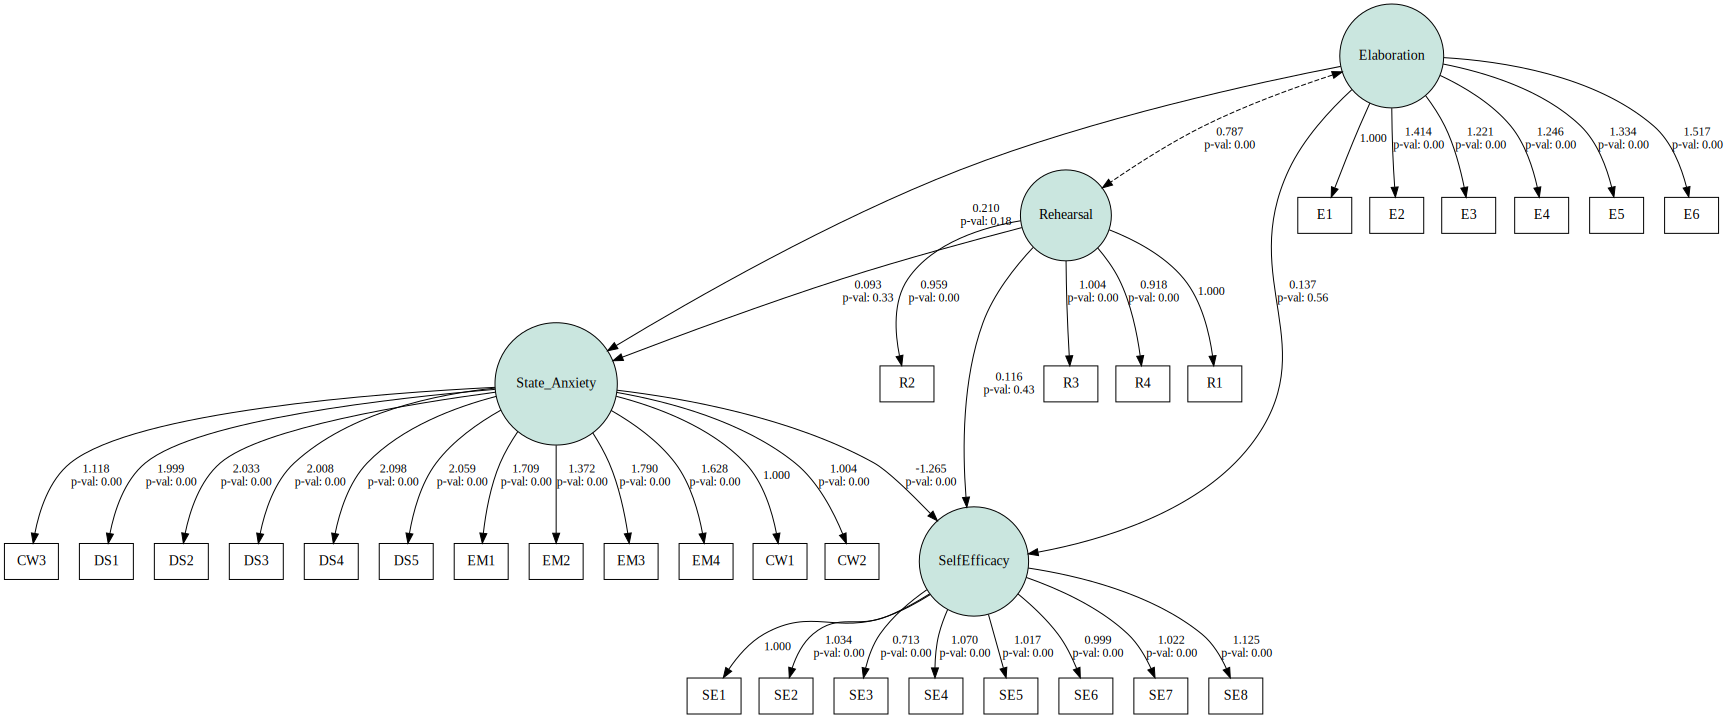

In [40]:
plot = semopy.semplot(model, "SEMmodel.png",plot_covs=True)
plot
